## $\texttt{Monte Carlo 101}$

### Monte Carlo 精度与撒点数
- 以在圆内撒点计算 $\pi$ 为例

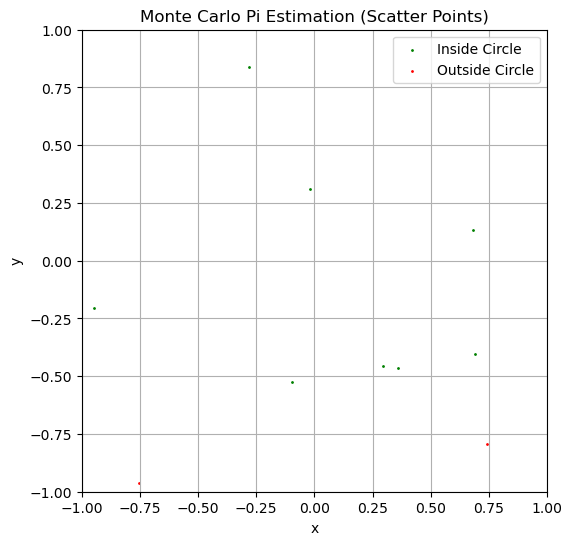

使用 10 个点估算的π值: 3.2


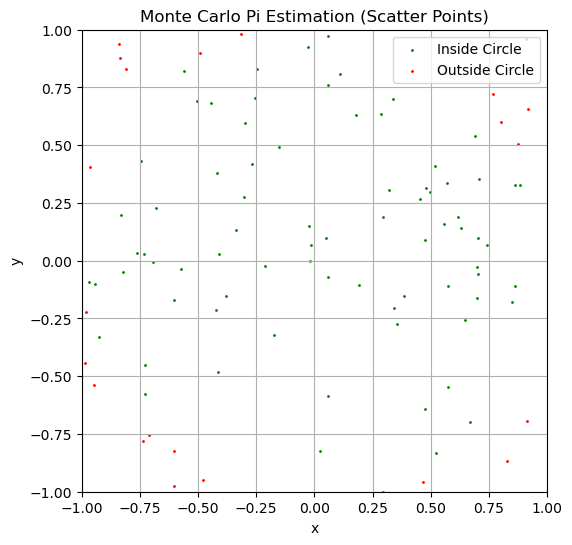

使用 100 个点估算的π值: 3.08


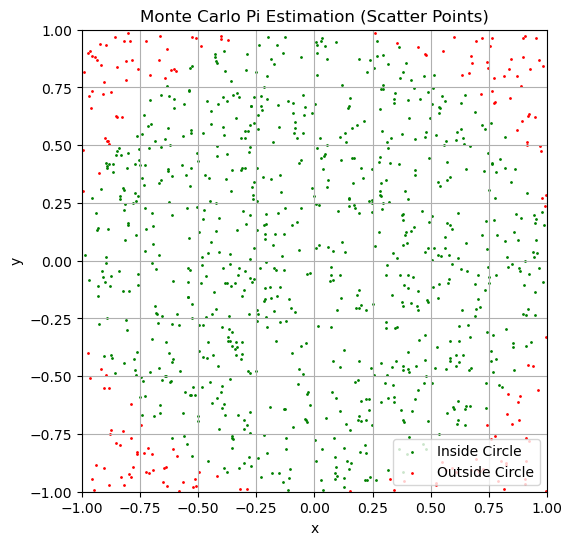

使用 1000 个点估算的π值: 3.268


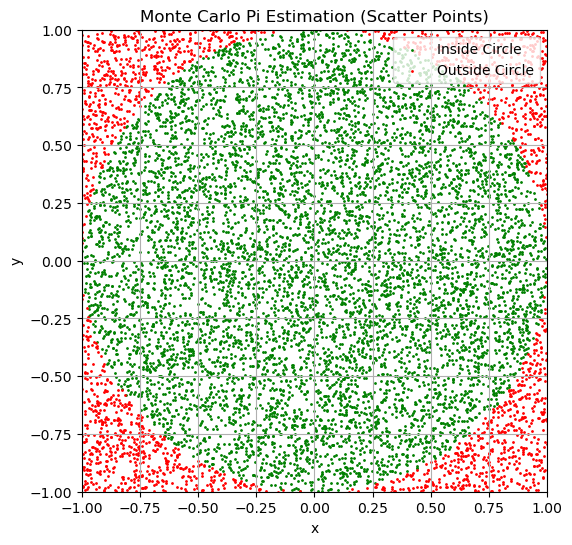

使用 10000 个点估算的π值: 3.1508


In [1]:
### 计算π值
import random
import matplotlib.pyplot as plt
import numpy as np

def monte_carlo_pi(num_points):
    inside_circle = 0  # 用于记录落在圆内的点的数量
    x_inside = []  # 存储圆内点的x坐标；# 创建一个空list
    y_inside = []  # 存储圆内点的y坐标
    x_outside = []  # 存储圆外点的x坐标
    y_outside = []  # 存储圆外点的y坐标

    for _ in range(num_points):  # 循环 num_points 次
        x = random.uniform(-1, 1)  # 随机生成x坐标
        y = random.uniform(-1, 1)  # 随机生成y坐标
        distance = x**2 + y**2  # 计算点到原点的距离的平方

        if distance <= 1:  # 判断点是否在单位圆内
            inside_circle += 1
            x_inside.append(x)
            y_inside.append(y)
        else:
            x_outside.append(x)
            y_outside.append(y)

    pi_estimate = 4 * (inside_circle / num_points)  # 估算π值

    # 绘制撒点过程
    plt.figure(figsize=(6, 6))
    plt.scatter(x_inside, y_inside, color='green', s=1, label="Inside Circle")  # 绘制散点图，圆内的点
    plt.scatter(x_outside, y_outside, color='red', s=1, label="Outside Circle")  # 圆外的点
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Monte Carlo Pi Estimation (Scatter Points)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return pi_estimate

# 示例: 使用 10000 个随机点进行估算
# estimated_pi = monte_carlo_pi(10000)
# print("估算的π值:", estimated_pi)
# 逐步增加点数，观察估算结果

points_list = [10, 100, 1000,10000]  # 逐渐增加的点数

for points in points_list:
    estimated_pi = monte_carlo_pi(points)
    print(f"使用 {points} 个点估算的π值: {estimated_pi}")

#### 研究精度随撒点数关系的变化

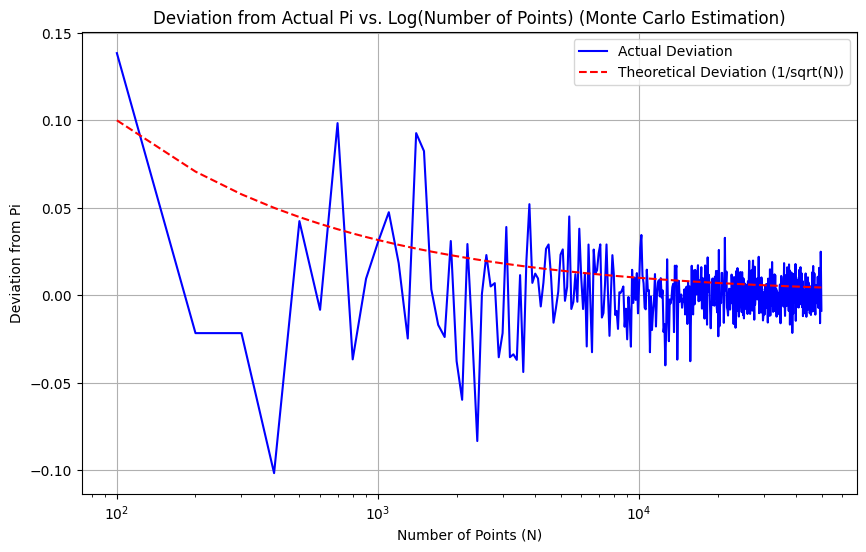

In [4]:
def monte_carlo_pi(num_points):
    inside_circle = 0  # 用于记录落在圆内的点的数量
    for _ in range(num_points):  # 循环 num_points 次
        x = random.uniform(-1, 1)  # 随机生成x坐标
        y = random.uniform(-1, 1)  # 随机生成y坐标
        distance = x**2 + y**2  # 计算点到原点的距离的平方
        if distance <= 1:  # 判断点是否在单位圆内
            inside_circle += 1
    pi_estimate = 4 * (inside_circle / num_points)  # 估算π值
    return pi_estimate

# 设置不同的点数
num_points_list = np.arange(100, 50000, 100)  # 从100到50000，步长为100
pi_values = []
pi_deviations = []
real_pi = np.pi  # 实际的π值

# 计算每个点数下的估算π值和偏差
for num_points in num_points_list:
    estimated_pi = monte_carlo_pi(num_points)
    pi_values.append(estimated_pi)
    pi_deviations.append(estimated_pi - real_pi)  # 计算估算值与真实值的偏差

# 理论偏差: 1 / sqrt(N)
theoretical_deviation = 1 / np.sqrt(num_points_list)

# 绘制偏差与理论偏差的对比图，x轴使用对数坐标
plt.figure(figsize=(10, 6))
plt.plot(num_points_list, pi_deviations, label="Actual Deviation", color='blue')
plt.plot(num_points_list, theoretical_deviation, label="Theoretical Deviation (1/sqrt(N))", color='red', linestyle='--')

# 设置x轴为对数坐标
plt.xscale('log')

plt.xlabel('Number of Points (N)')
plt.ylabel('Deviation from Pi')
plt.title('Deviation from Actual Pi vs. Log(Number of Points) (Monte Carlo Estimation)')
plt.grid(True)
plt.legend()
plt.show()


### 蒙特卡洛积分

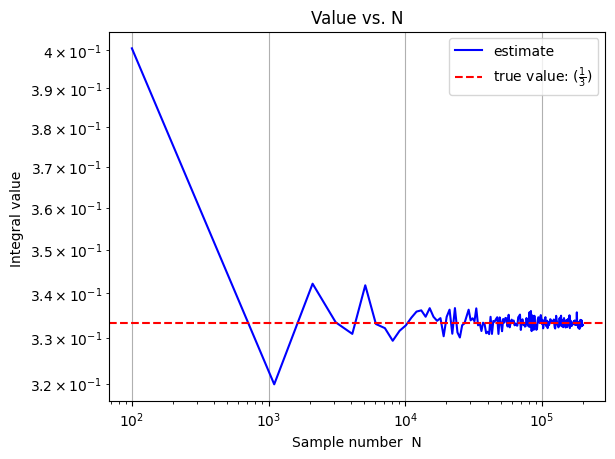

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 定义函数 f(x) = x^2
def f(x):
    return x**2

# 蒙特卡洛积分
def monte_carlo_integration(f, a, b, num_samples):
    # 在区间 [a, b] 中随机选择 num_samples 个点
    random_samples = np.random.uniform(a, b, num_samples)
    
    # 计算函数值
    function_values = f(random_samples)
    
    # 计算积分估算值
    integral_estimate = (b - a) * np.mean(function_values)
    return integral_estimate

# 定义区间 [a, b]
a = 0
b = 1
max_samples = 200000  # 最大样本点数量

# 计算不同样本数量下的积分估算值
sample_sizes = np.arange(100, max_samples + 1,1000)

integral_estimates = []  # 创建list


for n in sample_sizes:
    # 使用当前样本数量 n 计算蒙特卡洛积分
    integral_estimate = monte_carlo_integration(f, a, b, n)
    integral_estimates.append(integral_estimate)

# 真值
actual_integral = 1 / 3

# 积分估算值与样本数量的关系
plt.plot(sample_sizes, integral_estimates, label="estimate", color="blue")
plt.axhline(y=actual_integral, color='red', linestyle='--', label="true value: ($\\frac{1}{3}$)")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Sample number  N")
plt.ylabel("Integral value ")
plt.title("Value vs. N")
plt.legend()
plt.grid(True)
plt.show()

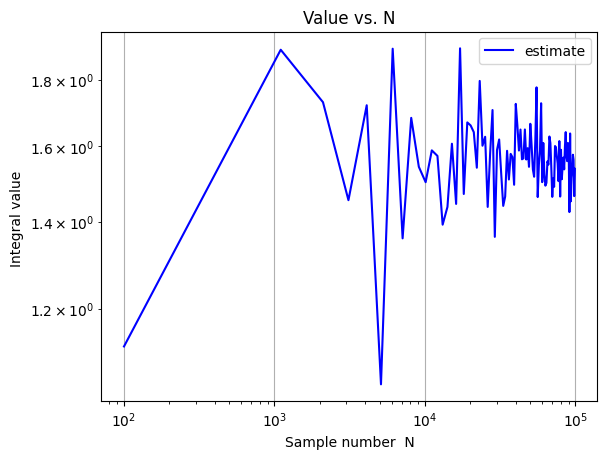

In [4]:
import numpy as np
from scipy.special import spherical_jn
import matplotlib.pyplot as plt
# -----------------------------
# 球贝塞尔函数 j0(x)
# -----------------------------
def j0(x):
    return spherical_jn(0, x)

# -----------------------------
# Monte Carlo 积分
# -----------------------------
def monte_carlo_integration(f, a, b, num_samples):

    x_samples = np.random.uniform(a, b, num_samples)

    integral_estimate = np.mean(f(x_samples))

    return (b - a) * integral_estimate


# -----------------------------
# 积分上限
# -----------------------------
a = 200

# 理论值 Si(a)
I_theoretical= np.pi/2 #

# -----------------------------
# Monte Carlo 测试
# -----------------------------
# sample_sizes = [1000, 10000, 100000]
# 注释掉的为ZL代码

sample_sizes = np.arange(100,100000+1,1000)

error_list = []
estimates = []

for N in sample_sizes:

    estimate = monte_carlo_integration(j0, 0, a, N)
    estimates.append(estimate)


    error = abs(estimate - I_theoretical)
    error_list.append(error)
    
    # 绘图版本就不要print了
    # print(f"N={N:8d} | MC={estimate:.6f} | "
    #       f"Error={error:.6e} | Theory={I_theoretical:.6f}")
    
# 积分估算值与样本数量的关系
plt.plot(sample_sizes, estimates, label="estimate", color="blue")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Sample number  N")
plt.ylabel("Integral value ")
plt.title("Value vs. N")
plt.legend()
plt.grid(True)
plt.show()

# $\texttt{MCMC}$
- Monte Carlo Markov Chain
- We will Learn About MH and Gibbs

### 马尔科夫链状态演化示例

该示例展示了如何使用转移矩阵模拟马尔科夫链的状态演化。我们将通过一个包含三个状态的马尔科夫链，计算并可视化状态的演变过程。

#### 1. 定义初始状态分布和转移矩阵

首先，我们定义初始状态分布向量 `x` 和转移矩阵 `P`。

- 初始状态向量 `x` 是一个包含三个元素的数组，表示系统在不同状态下的初始概率分布。例如，`x = [0.1, 0.1, 0.8]` 表示系统开始时有 10% 的概率处于状态 0，有 10% 的概率处于状态 1，以及 80% 的概率处于状态 2。

- 转移矩阵 `P` 描述了从当前状态转移到其他状态的概率。它是一个 3x3 的矩阵，每行表示从某个状态到其他状态的转移概率。例如，`P[0, 1] = 0.3` 表示从状态 0 转移到状态 1 的概率是 0.3。

### 转移矩阵示例：

$$
P = \begin{bmatrix}
    0.5 & 0.3 & 0.2 \\
    0.2 & 0.6 & 0.2 \\
    0.1 & 0.3 & 0.6
\end{bmatrix}
$$

#### 2. 运行马尔科夫链迭代

我们通过迭代来模拟马尔科夫链的状态演化。每次迭代通过矩阵乘法 `x = np.dot(x, P)` 更新当前状态向量 `x`。我们将进行 50 次迭代，记录每次迭代后的状态。

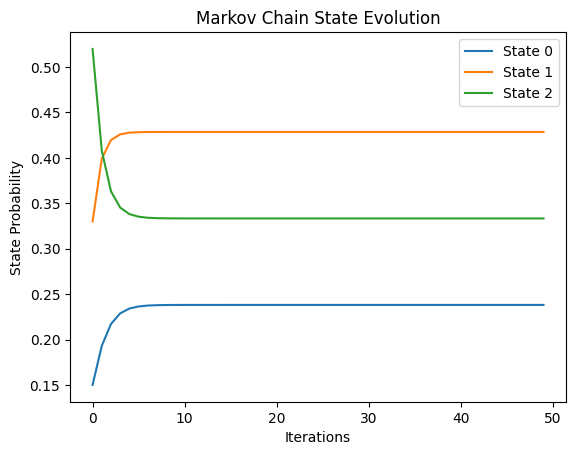

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 初始化状态行向量 x (例如： [1, 0, 0] 表示开始时状态在第一个位置)
x = np.array([0.1, 0.1, 0.8])

# 转移矩阵 P (假设是一个 3x3 的矩阵)
P = np.array([[0.5, 0.3, 0.2],   # 从状态 0 到各状态的转移概率
              [0.2, 0.6, 0.2],   # 从状态 1 到各状态的转移概率
              [0.1, 0.3, 0.6]])  # 从状态 2 到各状态的转移概率

# 运行马尔科夫链迭代
iterations = 50
states_over_time = []

for _ in range(iterations):
    x = np.dot(x, P)  # 更新状态
    states_over_time.append(x)

# 将状态演化过程可视化
states_over_time = np.array(states_over_time)

plt.plot(states_over_time)
plt.xlabel('Iterations')
plt.ylabel('State Probability')
plt.title('Markov Chain State Evolution')
plt.legend([f'State {i}' for i in range(len(x))], loc='upper right')
plt.show()

In [ ]:
# 50 states 
import numpy as np
import matplotlib.pyplot as plt

# 初始化状态行向量 x (假设每个状态的初始概率分布)
x = np.random.rand(50)  # 生成100个随机数
x /= np.sum(x)  # 归一化使得所有概率和为1

# 创建一个100x100的转移矩阵 P
# 在这个示例中，假设每个状态转移的概率是随机的
P = np.random.rand(50, 50)
P /= np.sum(P, axis=1)[:, np.newaxis]  # 确保每行的和为1

# 运行马尔科夫链迭代
iterations = 70
states_over_time = []

for _ in range(iterations):
    x = np.dot(x, P)  # 更新状态
    states_over_time.append(x)

# 将状态演化过程可视化
states_over_time = np.array(states_over_time)

plt.figure(figsize=(10, 6))
plt.plot(states_over_time)
plt.xlabel('Iterations')
plt.ylabel('State Probability')
plt.title('Markov Chain State Evolution (50 States)')
plt.legend([f'State {i}' for i in range(50)], loc='upper right', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### 马尔科夫链状态序列生成

在这个例子中，我们将使用一个包含三个状态（0，1，2）的马尔科夫链，通过转移概率矩阵和初始状态概率分布来生成状态序列。

#### 1. 定义转移概率矩阵

转移概率矩阵 $P$ 描述了从一个状态到其他状态的转移概率。假设有三个状态（0，1，2），那么转移矩阵 $P$ 是一个 $3 \times 3$ 的矩阵，其中每个元素 $P[i,j]$ 表示从状态 $i$ 转移到状态 $j$ 的概率。

例如，假设转移矩阵如下所示：

$$
P = \begin{bmatrix}
    0.5 & 0.3 & 0.2 \\
    0.2 & 0.6 & 0.2 \\
    0.1 & 0.3 & 0.6
\end{bmatrix}
$$

- 从状态 0 到其他状态的转移概率分别是 0.5、0.3 和 0.2。
- 从状态 1 到其他状态的转移概率分别是 0.2、0.6 和 0.2。
- 从状态 2 到其他状态的转移概率分别是 0.1、0.3 和 0.6。

#### 2. 定义初始状态概率分布

初始状态概率分布 $x$ 描述了马尔科夫链开始时各状态的概率。例如，若初始状态为状态 0，则：

$$
x = \begin{bmatrix} 1 & 0 & 0 \end{bmatrix}
$$

这表示系统开始时有 100% 的概率处于状态 0。

#### 3. 生成状态序列

为了生成状态序列，我们从初始状态开始，通过根据当前状态和转移矩阵随机选择下一个状态。这个过程不断迭代，直到生成所需长度的状态序列。

在每一步中，我们使用如下的随机选择方法来决定下一个状态：

$$
\text{next\_state} = \text{random choice from} \{0, 1, 2\}, 几率为 P[\text{current\_state}]
$$

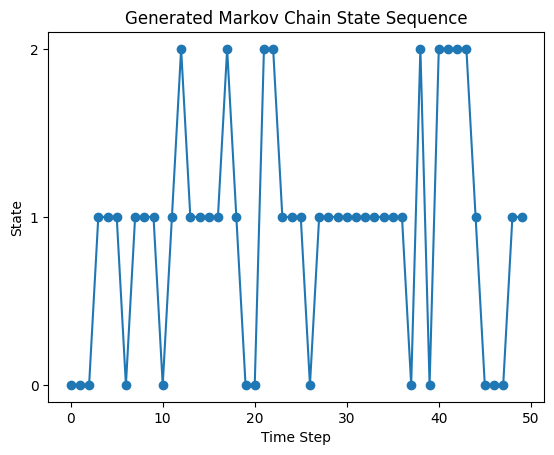

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 定义转移概率矩阵 P (3x3)，表示从每个状态到其他状态的转移概率
P = np.array([
    [0.5, 0.3, 0.2],  # 从状态 0 转移到状态 0, 1, 2 的概率
    [0.2, 0.6, 0.2],  # 从状态 1 转移到状态 0, 1, 2 的概率
    [0.1, 0.3, 0.6]   # 从状态 2 转移到状态 0, 1, 2 的概率
])

# 定义初始状态分布 x，表示系统开始时的状态
x = np.array([1, 0, 0])  # 初始状态为状态 0

# 生成状态序列的长度
num_steps = 50

# 创建一个空的列表，用于存储状态序列
state_sequence = [np.argmax(x)]  # 存储初始状态（索引为0的状态，即状态 0）

# 当前状态（从初始状态开始）
current_state = np.argmax(x)

# 开始生成状态序列
for _ in range(num_steps - 1):
    # 根据当前状态和转移矩阵选择下一个状态
    next_state = np.random.choice([0, 1, 2], p=P[current_state])
    state_sequence.append(next_state)
    current_state = next_state  # 更新当前状态为下一个状态

# 可视化状态序列
plt.plot(state_sequence, marker='o')
plt.xlabel('Time Step')
plt.ylabel('State')
plt.title('Generated Markov Chain State Sequence')
plt.yticks([0, 1, 2])
plt.show()

## $\texttt{Metropolis-Hastings}$ 算法示例


了解这个算法之前，我们应该知道，为什么我们需要这个算法。以我们希望求解某个积分为例：

| 步骤     | 工具            | 解决的问题                              |
| :----- | :------------ | :--------------------------------- |
| 写出积分   | 数学            | $I = \int f(x)p(x)dx$              |
| 识别为期望  | 概率论           | $I = \mathbb{E}_p[f(X)]$           |
| 生成样本   | **MH / MCMC** | 当 $p(x)$ 无法直接采样时，构造稳态为 $p(x)$ 的链   |
| 样本均值估计 | **蒙特卡洛**      | $\hat{I} = \frac{1}{N}\sum f(x_i)$ |


于是，$\texttt{Metropolis-Hastings}$ 的意义就显而易见了。

$\texttt{Metropolis-Hastings}$ 算法是一种基于马尔科夫链蒙特卡洛（MCMC）方法的采样算法，用于从复杂的概率分布中生成样本。它通过构建一个马尔科夫链，使得链的平稳分布为目标分布，从而实现样本的生成。

算法步骤

1. **初始化**：选择一个初始点 $x_0$。
2. **迭代**：
   - 从提议分布 $q(x'|x)$ 生成一个候选点 $x'$。
   - 计算接受概率 $\alpha(x, x')$：
     $$ \alpha(x, x') = \min \left( 1, \frac{p(x') q(x | x')}{p(x) q(x' | x)} \right) $$
     其中 $p(x)$ 是目标分布，$q(x'|x)$ 是提议分布。
   - 以接受率 $\alpha(x, x')$ 为概率决定是否接受候选点 $x'$，否则保持当前状态 $x$。
3. 重复以上步骤，直到收集到足够的样本。
  
提议分布（正态分布）：从当前值 $x_t$ 出发，从提议分布中抽样一个候选值 $y$。在这个例子中，我们选择一个均值为 $x_t$ ，方差为 $\sigma$ 的正态分布，即 $y \sim N(x_t, \sigma)$。

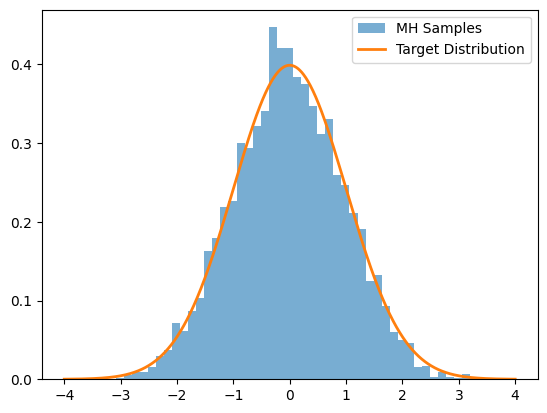

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def metropolis_hastings(target_pdf, proposal_sampler, num_samples=10000, init_x=0):
    samples = []
    x_t = init_x
    
    for _ in range(num_samples):
        x_star = proposal_sampler(x_t)  # 生成候选样本
        A = min(1, target_pdf(x_star) / target_pdf(x_t))  # 计算接受率
        
        if np.random.rand() < A:
            x_t = x_star  # 接受候选样本
        
        samples.append(x_t)
    
    return np.array(samples)

# 目标分布：标准正态分布
def target_pdf(x):
    return np.exp(-x**2 / 2)

# 高斯建议分布：N(x_t, 1)
sigma=1
def proposal_sampler(x):
    return x + np.random.normal(0, sigma) # sigma合适选取，增加接受率

# 运行 MH 采样
samples = metropolis_hastings(target_pdf, proposal_sampler)

# 绘制直方图
plt.hist(samples, bins=50, density=True, alpha=0.6, label="MH Samples")
x = np.linspace(-4, 4, 1000)
plt.plot(x, np.exp(-x**2 / 2) / np.sqrt(2 * np.pi), label="Target Distribution", linewidth=2)
plt.legend()
plt.show()

### 使用均匀分布作为提议分布


#### 1. 初始化：
选择一个初始值 $x_0$，作为马尔科夫链的起始状态。

#### 2. 提议：
从当前值 $x_t$ 出发，使用提议分布生成一个候选值 $y$。在这里，我们使用均匀分布 $U(x_t - \delta, x_t + \delta)$，即在当前状态 $x_t$ 的范围内均匀采样一个候选点 $y$，其中 $\delta$ 是一个调整范围的参数。

$$
y \sim U(x_t - \delta, x_t + \delta)
$$

#### 3. 计算接受概率：
计算接受概率 $\alpha$，它表示当前状态 $x_t$ 转移到候选点 $y$ 的概率。接受概率由目标分布的比值决定：

$$
\alpha = \min \left( 1, \frac{p(y)}{p(x_t)} \right)
$$

其中，$p(x)$ 表示目标分布在 $x$ 处的概率密度。

#### 4. 生成随机数：
从均匀分布 $U(0, 1)$ 中生成一个随机数 $u$。

#### 5. 决策：
如果 $u \leq \alpha$，则接受候选值 $y$，即令 $x_{t+1} = y$；否则，拒绝候选点 $y$，保持当前状态 $x_{t+1} = x_t$。

#### 6. 重复：
重复步骤 2 到步骤 5，直到收集到足够的样本。

在这个变体中，我们使用 **均匀分布** 作为提议分布，而不是传统的正态分布。均匀分布的优势在于其简单性，但在目标分布变化较大时，接受率可能较低，因此调整提议分布的范围 $\delta$ 对采样效率有重要影响。


#### 注意：
- 均匀分布的采样效率可能低，尤其是在目标分布存在显著变化时。因此，可以根据需要调整提议分布的宽度 $\delta$，以提高采样效率。

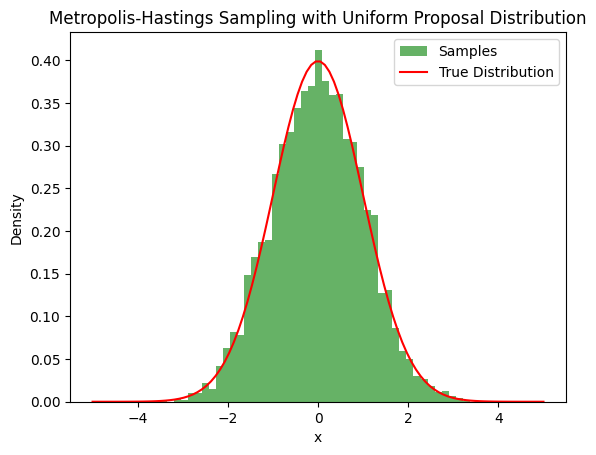

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 目标分布 p(x)，标准正态分布
def target_distribution(x):
    return np.exp(-0.5 * x**2)  # 标准正态分布的概率密度

# 提议分布 q(x'|x)，选择均匀分布 U(x_t - delta, x_t + delta)
def proposal_distribution(x, delta=1):
    return np.random.uniform(x - delta, x + delta)  # 从 x 出发，生成一个新的候选点

# Metropolis-Hastings算法
def metropolis_hastings(iterations, initial_state, delta=1):
    x = initial_state
    samples = [x]
    
    for _ in range(iterations):
        # 步骤2：从提议分布中抽样候选值 y
        y = proposal_distribution(x, delta)
        
        # 步骤3：计算接受概率 alpha
        alpha = min(1, target_distribution(y) / target_distribution(x))
        
        # 步骤4：生成随机数 u
        u = np.random.rand()
        
        # 步骤5：决策
        if u <= alpha:  # 如果 u <= alpha，接受 y
            x = y
        samples.append(x)  # 记录当前状态
    
    return np.array(samples)

# 运行Metropolis-Hastings算法
iterations = 10000
initial_state = 0  # 初始状态为0
delta =5  # 提议分布的范围
samples = metropolis_hastings(iterations, initial_state, delta)

# 可视化结果
plt.hist(samples, bins=50, density=True, alpha=0.6, color='g', label='Samples')
x = np.linspace(-5, 5, 100)
plt.plot(x, np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi), 'r', label='True Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.title('Metropolis-Hastings Sampling with Uniform Proposal Distribution')
plt.show()


### MH 非对称提议分布

####  **目标分布与提议分布**
在这个示例中，我们使用一个 **标准正态分布** $ \mathcal{N}(0, 1) $ 作为目标分布。标准正态分布的概率密度函数为：

$$
p(x) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{x^2}{2}\right)
$$

我们选择了一个 **非对称的提议分布** $ \mathcal{N}(x + \text{offset}, 1) $，
即以当前状态加上一个固定的偏移量（`offset`）为均值，标准差为1的正态分布。

这个提议分布的目标是生成接近当前状态的候选样本，但由于偏移量的存在，提议分布是非对称的。

#### **Metropolis-Hastings 算法**
Metropolis-Hastings 算法的基本步骤是：
1. **初始化状态** $ x_0 $。
2. **循环** 进行以下操作：
   - 从提议分布 $ q(y|x) $ 中生成一个候选样本 $ y $。
   - 计算接受概率 $ \alpha(x, y) $，其定义为：
   
   $$
   \alpha(x, y) = \min \left( 1, \frac{p(y)}{p(x)} \cdot \frac{q(x|y)}{q(y|x)} \right)
   $$
   其中，$ p(x) $ 和 $ p(y) $ 是目标分布的概率密度，$ q(x|y) $ 和 $ q(y|x) $ 是提议分布的密度。由于提议分布是非对称的，这两个项的比率是关键。
   - **接受或拒绝**：根据接受概率 $ \alpha(x, y) $ 来决定是否接受候选样本 $ y $。
   - 如果接受，则将 $ y $ 作为下一个状态，否则保持当前状态不变。
3. 重复上述过程，直到收集足够的样本。

#### **提议分布的概率密度**
在此代码中，提议分布的概率密度函数 $ q(y|x) $ 为：

$$
q(y|x) = \frac{1}{\sqrt{2\pi}} \exp\left( -\frac{(y - (x + \text{offset}))^2}{2} \right)
$$

它是一个以 $ x + \text{offset} $ 为均值的正态分布，标准差为1。由于我们在进行 Metropolis-Hastings 采样时，使用的是基于当前状态 $ x $ 的提议分布，所以提议分布的形状随着状态的不同而改变。


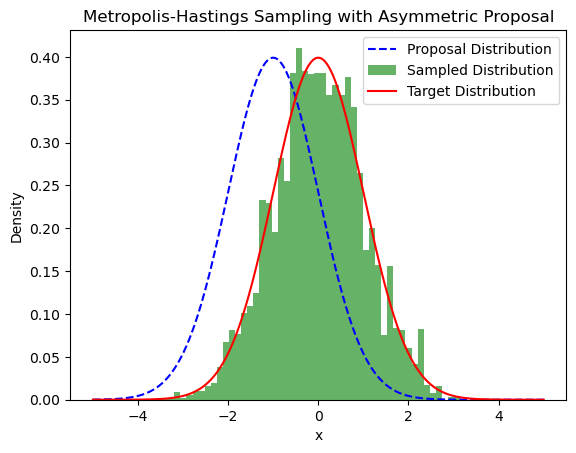

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 目标分布：标准正态分布 N(0,1)
def target_distribution(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

# 非对称提议分布：N(x + offset, 1)
def proposal_distribution(x, offset):
    return np.random.normal(x + offset, 1)

# 计算提议分布的转移概率密度，均使用相同的 offset
def proposal_density(x, y, offset):
    return np.exp(-0.5 * (y - (x + offset))**2) / np.sqrt(2 * np.pi)

# Metropolis-Hastings算法，加入burn-in期
def metropolis_hastings(target_dist, proposal_dist, proposal_density, offset, n_samples, initial_state, burn_in=1000):
    samples = []
    current_state = initial_state
    
    # 先进行 burn-in 期的采样
    for i in range(n_samples + burn_in):
        # 基于当前状态生成候选样本
        proposed_state = proposal_dist(current_state, offset)
        
        # 计算接受比率（始终使用 offset，不取反）
        ratio = (target_dist(proposed_state) / target_dist(current_state)) * \
                (proposal_density(proposed_state, current_state, offset) / \
                 proposal_density(current_state, proposed_state, offset))
        
        acceptance = min(1, ratio)
        
        # 接受候选样本
        if np.random.rand() < acceptance:
            current_state = proposed_state
        
        # 只保存 burn-in 之后的样本
        if i >= burn_in:
            samples.append(current_state)
    
    return np.array(samples)

# 参数设置
n_samples = 10000  # 有效采样数量
initial_state = 0  # 初始状态
offset = 1      # 非对称偏移量（可以尝试用更小的值）

# 运行Metropolis-Hastings算法
samples = metropolis_hastings(target_distribution, proposal_distribution, proposal_density, 
                              offset, n_samples, initial_state, burn_in=1000)


# 绘制提议分布（基于当前状态的提议分布）
proposal_x = np.linspace(-5, 5, 1000)
proposal_density_vals = [proposal_density(x, 0, offset) for x in proposal_x]  # 使用x=0作为当前状态

plt.plot(proposal_x, proposal_density_vals, 'b--', label='Proposal Distribution')

# 绘制采样结果
plt.hist(samples, bins=50, density=True, alpha=0.6, color='g', label='Sampled Distribution')
x = np.linspace(-5, 5, 1000)
plt.plot(x, target_distribution(x), 'r', label='Target Distribution')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Metropolis-Hastings Sampling with Asymmetric Proposal')
plt.legend()
plt.show()


### 使用 Metropolis-Hastings 计算积分  

我们希望计算如下积分：  

$
I = \int_0^\infty J_1(x) e^{-x^2} dx
$

其中：
- $J_1(x)$ 是第一类第一阶贝塞尔函数。
- $e^{-x^2}$ 是一个快速衰减的权重函数，使得积分主要贡献来自 $x \approx 0$ 附近。

---
由于积分的被积函数 $J_1(x)e^{-x^2}$ 不是标准分布，我们使用 **Metropolis-Hastings 采样** 结合 **蒙特卡洛方法** 进行近似计算。

**步骤**

1. **构造合适的采样分布**  
   选择目标分布 $p(x) \propto e^{-x^2}$，并要求 $x \geq 0$。
2. **使用 Metropolis-Hastings 采样**  
   - 生成一系列服从 $p(x)$ 的样本 $\{x_i\}$。
   - 由于 $p(x)$ 的归一化常数不影响积分计算，我们只需要比例关系 $p(x) \propto e^{-x^2}$。
3. **利用蒙特卡洛积分计算 $I$**
   $
   I \approx \frac{1}{N} \sum_{i=1}^{N} J_1(x_i)
$
   其中 $x_i$ 是 Metropolis-Hastings 采样得到的样本。

---

**Metropolis-Hastings 采样方法**

Metropolis-Hastings 采样是一种用于从复杂分布中抽取样本的 MCMC（马尔可夫链蒙特卡洛）方法。它的核心思想是：
1. **定义目标分布**：本例中，我们选择 $p(x) \propto e^{-x^2}$ 并限制 $x \geq 0$。
2. **选择候选分布**：
   - 这里，我们使用高斯分布 $\mathcal{N}(x, \sigma^2)$ 作为候选分布，即在当前状态 $x$ 的基础上加入一个小扰动。
3. **接受-拒绝准则**：
   - 计算候选点 $x'$ 的接受率：
     $
     A = \min\left(1, \frac{p(x')}{p(x)}\right) = \min(1, e^{x^2 - x'^2})
     $
   - 生成一个随机数 $u \sim U(0,1)$：
     - 若 $u < A$，则接受 $x'$ 作为新的样本。
     - 否则，保持当前样本不变。
4. **特定限制**：
   - 如果生成的候选点 $x' < 0$，直接拒绝并保持当前值不变。

---

**蒙特卡洛积分计算**

假设我们已获得 $N$ 个样本 $\{x_i\}$，则积分可以近似为：
$$
I \approx \frac{\sqrt{\pi}}{2}\frac{1}{N}\sum_{i=1}^{N}J_1(x_i).
$$

其中，$x_i$ 是从 $p(x) \propto e^{-x^2}$ 采样得到的, 这里 

$$
p(x)=\frac{2}{\sqrt{\pi}}e^{-x^2}, \qquad x\ge0, 
归一化因子： \int_0^{\infty} e^{-x^2} d x=\frac{\sqrt{\pi}}{2}
$$

---

最后一部分对比一下数值积分解


Acceptance rate = 0.21464
估计的积分值 I ≈ 0.220883


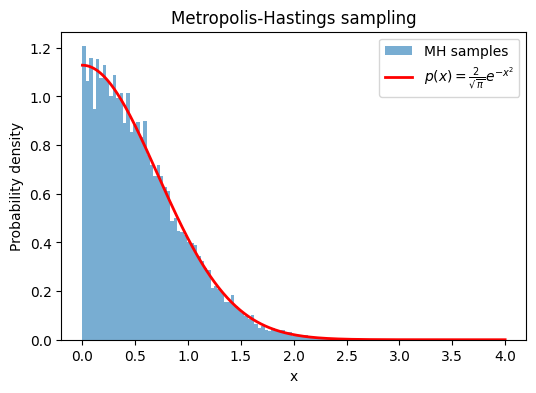

Integral result: 0.2211992169285951, Error estimate: 6.51861152811279e-13


In [10]:
import numpy as np
from scipy.integrate import quad
from scipy.special import jn
import matplotlib.pyplot as plt
from scipy.special import j1

# -----------------------
# Metropolis-Hastings
# -----------------------
def metropolis_hastings(proposal_std, num_samples, x_init=1.0):

    samples = np.zeros(num_samples)
    x = x_init
    accept = 0

    for i in range(num_samples):

        x_new = np.random.normal(x, proposal_std)

        if x_new < 0:
            samples[i] = x
            continue

        acceptance_ratio = np.exp(x**2 - x_new**2)

        if np.random.rand() < acceptance_ratio:
            x = x_new
            accept += 1

        samples[i] = x

    print("Acceptance rate =", accept/num_samples)

    return samples


# -----------------------
# 采样
# -----------------------
num_samples = 100000
samples = metropolis_hastings(proposal_std=2.0, num_samples=num_samples)

# burn-in
burn = 5000
samples = samples[burn:]


# -----------------------
# Monte Carlo 积分
# -----------------------
integral_estimate = np.sqrt(np.pi)/2 * np.mean(j1(samples))

print(f"估计的积分值 I ≈ {integral_estimate:.6f}")


# -----------------------
# 绘制样本分布
# -----------------------
x_vals = np.linspace(0,4,500)

# 理论分布
p = 2/np.sqrt(np.pi) * np.exp(-x_vals**2)

plt.figure(figsize=(6,4))

plt.hist(samples,
         bins=100,
         density=True,
         alpha=0.6,
         label="MH samples")

plt.plot(x_vals,
         p,
         'r',
         lw=2,
         label=r"$p(x)=\frac{2}{\sqrt{\pi}}e^{-x^2}$")

plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Metropolis-Hastings sampling")
plt.legend()

plt.show()

# Define the integrand
def integrand(x):
    return jn(1, x) * np.exp(-x**2)

# Perform the integration with increased accuracy
result, error = quad(integrand, 0, np.inf, epsabs=1e-12, epsrel=1e-12)

print(f"Integral result: {result}, Error estimate: {error}")

## $\texttt{Gibbs}$

在二维高斯分布中，Gibbs 采样的条件概率计算过程如下：

假设目标分布为 $p(x, y)$，即二维高斯分布，具有均值向量 $\mu = (\mu_x, \mu_y)$ 和协方差矩阵 $\Sigma = \begin{pmatrix} \sigma_x^2 & \rho \sigma_x \sigma_y \\ \rho \sigma_x \sigma_y & \sigma_y^2 \end{pmatrix}$。

#### 1. 采样 $p(x | y)$：
在给定 $y$ 的条件下，$x$ 的条件概率分布为：
$$
p(x | y) = \mathcal{N}(x | \mu_x + \rho \cdot \frac{\sigma_x}{\sigma_y} (y - \mu_y), \sigma_x^2 (1 - \rho^2))
$$
其中：
- $\mu_x$ 是 $x$ 的均值，
- $\mu_y$ 是 $y$ 的均值，
- $\sigma_x$ 和 $\sigma_y$ 分别是 $x$ 和 $y$ 的标准差，
- $\rho$ 是 $x$ 和 $y$ 之间的相关系数。

#### 2. 采样 $p(y | x)$：
在给定 $x$ 的条件下，$y$ 的条件概率分布为：
$$
p(y | x) = \mathcal{N}(y | \mu_y + \rho \cdot \frac{\sigma_y}{\sigma_x} (x - \mu_x), \sigma_y^2 (1 - \rho^2))
$$
其中：
- $\mu_x$ 是 $x$ 的均值，
- $\mu_y$ 是 $y$ 的均值，
- $\sigma_x$ 和 $\sigma_y$ 分别是 $x$ 和 $y$ 的标准差，
- $\rho$ 是 $x$ 和 $y$ 之间的相关系数。

#### 3. 采样过程：
- 初始化 $(x_0, y_0)$。
- 对于每一轮迭代：
  - 先根据当前的 $y$ 值采样 $x$，使用条件分布 $p(x | y)$。
  - 然后根据新的 $x$ 值采样 $y$，使用条件分布 $p(y | x)$。

#### 4. 收敛性：
通过多次迭代，Gibbs 采样的样本将逐渐收敛于目标分布 $p(x, y)$，从而生成符合二维高斯分布的样本。



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

def gibbs_sampling(mu, sigma, num_samples=1000, burn_in=100):
    """
    Gibbs 采样，用于从二维高斯分布中生成样本。
    :param mu: 均值向量 [mu_x, mu_y]
    :param sigma: 协方差矩阵 [[var_x, cov_xy], [cov_xy, var_y]]
    :param num_samples: 采样数量
    :param burn_in: 扔掉的初始采样数
    :return: 采样点的数组
    """
    samples = np.zeros((num_samples + burn_in, 2))
    x, y = 0, 0  # 初始值
    
    sigma_x = np.sqrt(sigma[0, 0])
    sigma_y = np.sqrt(sigma[1, 1])
    rho = sigma[0, 1] / (sigma_x * sigma_y)  # 相关系数
    
    for i in range(num_samples + burn_in):
        # 采样 x | y
        mu_x_given_y = mu[0] + rho * (sigma_x / sigma_y) * (y - mu[1])
        sigma_x_given_y = sigma_x * np.sqrt(1 - rho**2)
        x = np.random.normal(mu_x_given_y, sigma_x_given_y)
        
        # 采样 y | x
        mu_y_given_x = mu[1] + rho * (sigma_y / sigma_x) * (x - mu[0])
        sigma_y_given_x = sigma_y * np.sqrt(1 - rho**2)
        y = np.random.normal(mu_y_given_x, sigma_y_given_x)
        
        samples[i] = [x, y]
    
    return samples[burn_in:]  # 去掉 burn-in 期样本

# 定义均值和协方差
mu = [0, 0]
sigma = np.array([[2.0, 0.8], [0.8, 1.0]])

# 运行 Gibbs 采样
samples = gibbs_sampling(mu, sigma, num_samples=5000)

# 创建网格以计算目标分布的密度
x = np.linspace(min(samples[:, 0]) - 1, max(samples[:, 0]) + 1, 500)
y = np.linspace(min(samples[:, 1]) - 1, max(samples[:, 1]) + 1, 500)
X, Y = np.meshgrid(x, y)

# 目标分布的均值和协方差
Z = multivariate_normal(mu, sigma).pdf(np.dstack((X, Y)))

# 可视化采样结果和目标分布
plt.figure(figsize=(6, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=5, label="Gibbs Samples")
plt.contour(X, Y, Z, levels=10, cmap='viridis', alpha=0.6)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Gibbs Sampling from 2D Normal Distribution with Target Distribution")
plt.legend()
plt.show()


## 一维 Ising 模型的 MCMC 模拟

#### 模拟过程

采用 Metropolis-Hastings 算法来模拟一维 Ising 模型的自旋系统随温度的演化。

$E=-J \sum_{i=1}^N s_i s_{i+1}$; 自旋取值是-1或+1

主要步骤如下：

1. **初始化**：
   - 在一维链上生成 $N$ 个自旋，取值为 $\pm1$。
   - 自旋可以随机初始化，或从某个特定的初始状态（如全为 $+1$ 或随机分布）开始。

2. **Metropolis 更新**（每一步包括以下操作）：系统通过单步更新（即每次翻转一个自旋）从当前状态转移到一个新状态
   - 随机选择一个自旋 $s_i$。翻转 $s_i$ 后，其取值变为 $-s_i$。
   - 计算翻转该自旋的能量变化 $\Delta E$：
     $
     \Delta E = 2 J s_i (s_{i-1} + s_{i+1})
     $
     其中 $J$ 是相互作用强度。
   - 以概率 $P = e^{-\beta \Delta E}$ 接受该翻转（其中 $\beta = 1/(k_B T)$），否则保持不变。

   - 上述过程重复足够多次，使系统达到平衡。
   - 观察能量随步数变化的趋势。
  

#### Metropolis-Hastings 算法

1. 计算当前状态的能量。
2. 选择一个候选状态（例如，随机翻转一个自旋）。
3. 计算能量变化 $\Delta E$，并决定是否接受该变化：
   - 如果 $\Delta E < 0$，直接接受。
   - 如果 $\Delta E > 0$，则以概率 $e^{-\beta \Delta E}$ 接受。
4. 重复上述步骤，使系统逐步趋近平衡。

该方法确保了最终状态分布服从平衡态的 Boltzmann 分布：
$
P(s) \propto e^{-\beta E(s)}
$

#### 结果分析

- 在低温（高 $\beta$）下，自旋趋于排列整齐（长程有序）。
- 在高温（低 $\beta$）下，自旋趋于随机分布（无序状态）。

本模拟可以扩展到更高维度，如二维和三维 Ising 模型，以研究相变现象。

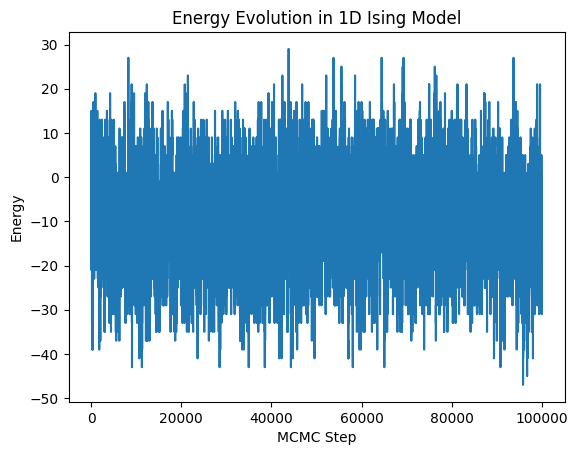

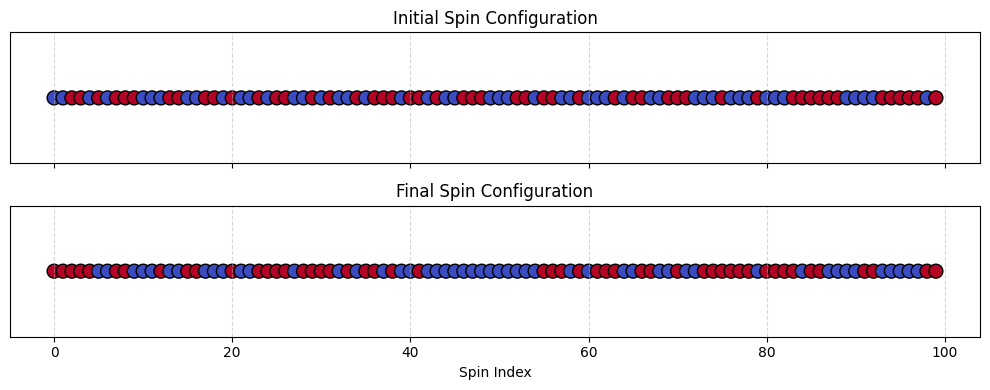

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def energy(spins, J=1):
    """计算一维 Ising 模型的总能量"""
    return -J * np.sum(spins[:-1] * spins[1:])

def metropolis_step(spins, beta, J=1):
    """执行 Metropolis-Hastings 更新"""
    N = len(spins)
    i = np.random.randint(N)  # 随机选择一个自旋翻转
# 获取当前自旋 i 的左邻居和右邻居，手动处理边界条件
    if i == 0:
        left_neighbour = spins[N - 1]  # 最左边的自旋，周期性边界条件
    else:
        left_neighbour = spins[i - 1]  # 自旋 i 的左邻居

    if i == N - 1:
        right_neighbour = spins[0]  # 最右边的自旋，周期性边界条件
    else:
        right_neighbour = spins[i + 1]  # 自旋 i 的右邻居

# 计算能量变化
    delta_E = 2 * J * spins[i] * (left_neighbour + right_neighbour)
    
    if delta_E < 0 or np.random.rand() < np.exp(-beta * delta_E):
        spins[i] *= -1  # 接受翻转

def ising_mcmc(N, init_spins, beta, steps):
    """运行 MCMC 以模拟一维 Ising 模型"""
    spins = init_spins.copy()  # 如果 init_spins 是列表

    energies = []
    
    for _ in range(steps):
        metropolis_step(spins, beta)
        energies.append(energy(spins))
    
    return spins, energies

# 参数设定
N = 100  # 自旋数
beta = 0.1  # 逆温度 1/(kT)
steps = 100000  # MCMC 迭代步数
init_spins = np.random.choice([-1, 1], size=N)  # 随机初始化自旋
# 运行模拟
final_spins, energies = ising_mcmc(N, init_spins, beta, steps)

# 绘制能量随迭代步数变化
plt.plot(energies)
plt.xlabel("MCMC Step")
plt.ylabel("Energy")
plt.title("Energy Evolution in 1D Ising Model")
plt.show()

# 绘图
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

# 初始状态
axes[0].scatter(range(N), [0] * N, c=init_spins, cmap='coolwarm', s=100, edgecolors='k')
axes[0].set_title("Initial Spin Configuration")
axes[0].set_yticks([])  # 隐藏 y 轴刻度
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# 最终状态
axes[1].scatter(range(N), [0] * N, c=final_spins, cmap='coolwarm', s=100, edgecolors='k')
axes[1].set_title("Final Spin Configuration")
axes[1].set_yticks([])  # 隐藏 y 轴刻度
axes[1].set_xlabel("Spin Index")
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### 2d Ising Model

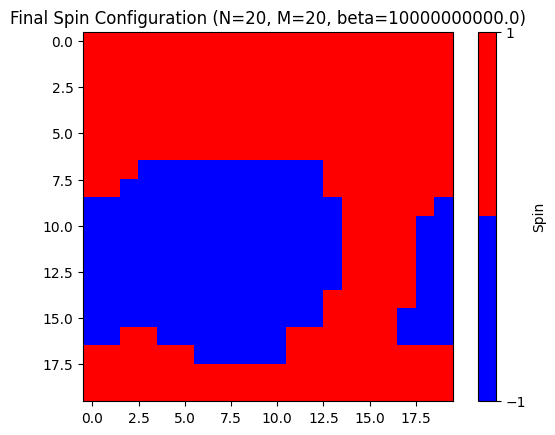

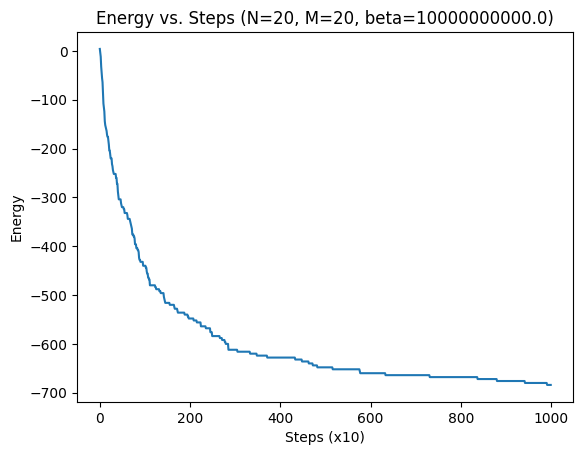

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def metropolis_step(spins, beta, J=1):
    """执行 Metropolis-Hastings 更新"""
    N, M = spins.shape
    i, j = np.random.randint(0, N), np.random.randint(0, M)  # 随机选择一个自旋
    
    # 计算邻居相互作用
    neighbors = spins[(i - 1) % N, j] + spins[(i + 1) % N, j] + \
                spins[i, (j - 1) % M] + spins[i, (j + 1) % M]
    
    delta_E = 2 * J * spins[i, j] * neighbors  # 翻转自旋的能量变化
    
    # Metropolis 规则
    if delta_E < 0 or np.random.rand() < np.exp(-beta * delta_E):
        spins[i, j] = -spins[i, j]  # 接受翻转

def compute_energy(spins, J=1):
    """计算总能量，考虑周期性边界"""
    N, M = spins.shape
    energy = -J * np.sum(
        spins * np.roll(spins, shift=1, axis=0) +  # 垂直方向（上）
        spins * np.roll(spins, shift=-1, axis=0) + # 垂直方向（下）
        spins * np.roll(spins, shift=1, axis=1) +  # 水平方向（左）
        spins * np.roll(spins, shift=-1, axis=1)   # 水平方向（右）
    ) / 2  # 每个相互作用计算了两次，需除以2
    return energy

def simulate_ising(N, M, beta, J=1, steps=1000):
    """模拟二维伊辛模型"""
    spins = np.random.choice([-1, 1], size=(N, M))  # 初始化自旋矩阵
    energy_list = []
    
    for step in range(steps):
        metropolis_step(spins, beta, J)  # 进行一次 Metropolis 更新
        if step % 10 == 0:  # 每10步计算一次总能量，提高效率
            energy_list.append(compute_energy(spins, J))
    
    return spins, energy_list

# 参数
N, M = 20, 20  # 自旋矩阵大小
T= 1e-10    # 温度
beta=1/T
steps = 10000  # 总步数

# 运行模拟
spins, energy_list = simulate_ising(N, M, beta, steps=steps)

# 画出最终自旋状态
cmap = mcolors.ListedColormap(['blue', 'red'])  # -1 对应蓝色，+1 对应红色
plt.imshow(spins, cmap=cmap, vmin=-1, vmax=1)
plt.title(f'Final Spin Configuration (N={N}, M={M}, beta={beta})')
plt.colorbar(label='Spin', ticks=[-1, 1])
plt.show()
# 画出能量变化
plt.plot(energy_list)
plt.title(f'Energy vs. Steps (N={N}, M={M}, beta={beta})')
plt.xlabel('Steps (x10)')
plt.ylabel('Energy')
plt.show()


### **计算二维伊辛模型的平均磁化率 \( M \)**

这是一个比较实在的物理问题，因为和相变相关

**1. 定义磁化率**
在二维伊辛模型（2D Ising Model）中系统的**总磁矩**（total magnetization）定义为：
$
M_{\text{total}} = \sum_{i,j} S_{i,j}
$
其中求和遍历整个的自旋矩阵。

为了得到**平均磁化率**（magnetization per spin），我们归一化总磁矩：
$
M = \frac{1}{N M} \sum_{i,j} S_{i,j}
$
由于相变主要关注磁化率的大小，而非方向，我们通常计算**绝对值的平均磁化率**：$
M = \frac{1}{N M} \left| \sum_{i,j} S_{i,j} \right|
$

---
**2. 物理意义**
- **低温（$ T < T_c $）**: $ M \approx 1 $，表明大部分自旋趋于一致（铁磁态）。
- **高温（$T > T_c $）**: $ M \approx 0 $，表明自旋随机分布（顺磁态）。
- **相变温度（$ T \approx T_c $）**:  $M$  迅速下降，标志着从有序到无序的转变。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sweep(spins, beta):

    L = spins.shape[0]

    for _ in range(L*L):

        i = np.random.randint(0, L)
        j = np.random.randint(0, L)

        s = spins[i, j]

        neighbors = (
            spins[(i+1) % L, j] +
            spins[(i-1) % L, j] +
            spins[i, (j+1) % L] +
            spins[i, (j-1) % L]
        )

        dE = 2 * s * neighbors

        if dE <= 0 or np.random.rand() < np.exp(-beta * dE):
            spins[i, j] = -s


def magnetization(spins):
    return np.abs(np.sum(spins)) / spins.size


def simulate_T(L, beta, burn_in, steps):

    spins = np.random.choice(np.array([-1, 1]), size=(L, L))

    # ---------- thermalization ----------
#在热化阶段，我们进行 burn_in 次蒙特卡洛更新（即 sweep 函数）。在每次更新中，
#自旋矩阵 spins 被逐步调整，直到系统达到热平衡（即不再依赖于初始配置）。这一阶段不进行磁化强度的计算，目的是让系统从随机初始状态过渡到平衡态。    
    for _ in range(burn_in):  
        sweep(spins, beta)

    mags = np.zeros(steps)

    # ---------- measurement ----------
#经过热化阶段后，进行 steps 次测量，每次测量中：
#调用 sweep(spins, beta) 进行一次自旋更新。
#计算当前自旋配置下的磁化强度 mags[i] = magnetization(spins)。
#magnetization(spins) 计算当前系统的磁化强度。这个磁化强度是通过求取自旋矩阵所有自旋的
    for i in range(steps):
        sweep(spins, beta)
        mags[i] = magnetization(spins)
#最后，函数返回所有测量步骤中磁化强度的平均值。通过 np.mean(mags)，我们得到系统在该温度下的平均磁化强度。
    return np.mean(mags)


L = 20
burn_in = 2000
steps = 2000

T_list = np.linspace(1.5, 4, 10)

M_mc = []

for T in T_list:

    beta = 1 / T

    m = simulate_T(L, beta, burn_in, steps)

    print(T, m)

    M_mc.append(m)

Tc = 2 / np.log(1 + np.sqrt(2))

M_exact = []

for T in T_list:

    if T < Tc:
        m = (1 - np.sinh(2 / T) ** (-4)) ** (1 / 8)
    else:
        m = 0

    M_exact.append(m)

plt.figure(figsize=(6, 5))

plt.plot(T_list, M_mc, 'o', label="Monte Carlo")
plt.plot(T_list, M_exact, 'r-', lw=2, label="Exact")

plt.axvline(Tc, color='gray', ls='--', label='Tc')

plt.xlabel("Temperature")
plt.ylabel("Magnetization")
plt.title("2D Ising Phase Transition")
plt.legend()

plt.show()

## MCMC 估计后验分布
先对贝叶斯定理有一个直观理解：

### 贝叶斯定理

$$p(\theta \mid \text{data}) = \frac{p(\text{data} \mid \theta)\, p(\theta)}{p(\text{data})}$$

---

1. 先验概率 $p(\theta)$

**定义**：观测到任何数据之前，我们对参数 $\theta$ 的初始信念。

**具体例子**：假设有一种罕见疾病在人群中的患病率为 $1\%$。你随机抽取一个人，在没有任何检测信息之前，你认为他患病的概率就是：

$$p(\theta=\text{患病}) = 0.01$$

这个 $1\%$ 就是先验概率。它来自历史统计或领域经验，是你在看到"检测数据"之前的起点。

---

2. 似然函数 $p(\text{data} \mid \theta)$

**定义**：在假设参数 $\theta$ 为真的前提下，观测到当前数据的可能性。

**具体例子**：假设你使用一种试剂盒检测上述疾病。已知：
- 如果一个人**确实患病**，试剂盒显示阳性的概率（灵敏度）是 $99\%$；
- 如果一个人**确实患病**，试剂盒显示阴性的概率是 $1\%$。

那么，当你已知某人患病（$\theta=\text{患病}$）时，观测到"检测结果为阳性"（data = 阳性）的概率就是：

$$p(\text{data}=\text{阳性} \mid \theta=\text{患病}) = 0.99$$

这就是似然。它回答的是：**假设我的模型/参数是对的，我看到这样的数据有多合理？** 注意，它不是"患病概率"，而是"在已患病条件下检测出阳性的概率"。

---

3. 边缘似然性 $p(\text{data})$

**定义**：不考虑任何参数假设的情况下，观测到当前数据的整体概率。它是所有可能参数路径下产生该数据的总和（或积分），起到归一化作用。

**具体例子**：沿用上面的疾病检测。你还知道：
- 健康人群中被误检为阳性的概率（假阳性率）是 $5\%$；
- 人群中有 $99\%$ 的人是健康的。

现在，你随机抽一个人，**在还不知道他是否患病的情况下**，他检测结果为阳性的总概率是多少？这需要把两条路径加起来：

$$
\begin{aligned}
p(\text{data}=\text{阳性}) &= p(\text{阳性}\mid\text{患病})\,p(\text{患病}) + p(\text{阳性}\mid\text{健康})\,p(\text{健康}) \\
&= 0.99 \times 0.01 + 0.05 \times 0.99 \\
&= 0.0099 + 0.0495 \\
&= 0.0594
\end{aligned}
$$

也就是说，随机抽一个人检测，约有 $5.94\%$ 的概率得到阳性结果。这个 $p(\text{data})$ 是贝叶斯公式的分母，确保后验概率之和为 $1$。

---

4. 后验分布 $p(\theta \mid \text{data})$

**定义**：在观测到数据之后，我们对参数 $\theta$ 的更新信念。它是贝叶斯推断的终极目标——把先验知识和观测证据融合成更准确的判断。

**具体例子**：现在，你随机抽了一个人，试剂盒显示**阳性**。请问，他**真正患病的概率**是多少？

直观上，你可能会觉得"检测准确率 $99\%$，那应该差不多 $99\%$ 患病"。但贝叶斯计算会给你一个反直觉的答案：

$$
\begin{aligned}
p(\theta=\text{患病} \mid \text{data}=\text{阳性}) &= \frac{p(\text{阳性}\mid\text{患病})\,p(\text{患病})}{p(\text{阳性})} \\[6pt]
&= \frac{0.99 \times 0.01}{0.0594} \\[6pt]
&= \frac{0.0099}{0.0594} \\[6pt]
&\approx 0.1667
\end{aligned}
$$

**结果**：即使检测呈阳性，真正患病的概率只有约 **$16.7\%$**！

为什么？因为疾病本身太罕见（先验只有 $1\%$），而假阳性在庞大健康人群中累积的数量压倒了真阳性。后验概率把这一点精确地量化了——它把你的先验（$1\%$ 患病率）和似然（$99\%$ 灵敏度）通过数据（阳性结果）融合，给出了一个远比直觉更准确的答案。





### MCMC 估计身高的后验分布

#### 1. 问题描述
在测量身高时，由于测量仪器的精度限制和随机误差，测量数据通常会受到高斯噪声的影响。给定一组测量数据，我们希望通过贝叶斯方法估计真实身高 $h$ 及其分布。

#### 2. 贝叶斯推断
根据贝叶斯定理，后验分布由以下公式给出：
$$ P(h | D) \propto P(D | h) P(h) $$
由于假设先验分布是均匀分布（等价于 1），后验分布的主要贡献来自似然函数：
$$ P(h | D) \propto P(D | h) $$
其中，似然函数假设测量数据服从均值为 $h$ 的高斯分布：
$$ P(D | h) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(d_i - h)^2}{2\sigma^2}\right) $$
为了估计 $P(h | D)$ 的分布，我们采用 MCMC 方法进行采样。

#### 3. MCMC 采样方法
使用 Metropolis-Hastings 算法，我们可以构造一条马尔可夫链，使其渐进收敛到目标分布 $P(h | D)$。

**采样步骤**
1. **初始化**：设定初始身高 $h_0$，通常可以使用测量数据的均值作为初始值。
2. **生成新候选值**：
   - 设定提议分布为高斯分布，即：
     $$ h' \sim \mathcal{N}(h, \sigma_p) $$
     其中，$\sigma_p$ 为提议步长，通常设置为 1。
3. **计算接受率**：
   - 计算新候选值的似然比：
     $$ r = \frac{P(D | h')}{P(D | h)} $$
   - 计算接受概率：
     $$ \alpha = \min(1, r) $$
4. **接受或拒绝新候选值**：
   - 生成一个均匀分布随机数 $u \sim U(0,1)$。
   - 若 $u < \alpha$，则接受 $h'$ 作为新状态；否则保持当前的 $h$ 不变。
5. **重复步骤 2 - 4**，直到采样足够的样本。

#### 4. 真实分布对比
理论上，真实的身高分布也是一个高斯分布，其均值为真实身高 $h_{\text{true}}$，方差由测量误差决定：
$$ h_{\text{true}} \sim \mathcal{N}(h_{\text{true}}, \frac{\sigma}{\sqrt{n}}) $$
其中 $n$ 是测量次数，$\sigma$ 是测量噪声标准差。我们将 MCMC 得到的后验分布与该真实分布进行对比，以验证 MCMC 采样的正确性。

#### 5. 结果分析
- 通过 MCMC 采样得到的后验分布应该与真实分布接近，均值接近真实身高 $h_{\text{true}}$，方差取决于测量误差和测量次数。
- 采样的数量越多，后验分布越平滑，并且与真实分布的拟合度越高。

### $\textcolor{red}{思考}$

从上述的过程来看，我们可以发现有一个细节：

>其中，似然函数假设测量数据服从均值为 $h$ 的高斯分布：

这是一个很有趣的点。$p(\theta)$肯定是能从数据中得到的，但是作为似然函数的 $P(D | h)$ 能从数据中得到吗？还是我们只能假设？

**答案是：只能假设。**

--

#### 1. 参数和数据是两回事

首先要分清两个概念：

| | 真实身高 $h$ | 测量读数 $d_i$ |
|:---|:---|:---|
| **是什么** | 这个人的客观身高（固定不变） | 卷尺上显示的数字（每次看都可能不同） |
| **角色** | 你想估计的**未知常数** | 你实际拿到的**观测结果** |
| **随机性** | 没有随机性（只是你不知道） | **有随机性**（手抖、仪器精度、 rounding） |

真实身高是 $175.0$ cm，这是客观事实。但你测出来的读数是 $170.2$ cm——**不是这个人缩水了，而是你的卷尺在骗你。**

想象你真的拿一把卷尺去量一个身高 $175$ cm 的人：

- 卷尺没拉直，少读了 $3$ cm；
- 他站得不直，弯了 $1$ cm；
- 你眼睛看刻度时偏了 $0.8$ cm；
- 卷尺本身刻度有 manufacturing tolerance。

这些微小因素叠加在一起，最终读数变成了 $170.2$。**真实身高没变，变的是测量过程引入的噪声。** 这就是模型里的 $\varepsilon_i$：

$$d_i = \underbrace{h}_{\text{真值 }175.0} + \underbrace{\varepsilon_i}_{\text{噪声 }-4.8}$$

---

#### 2. 数据只有一组，但似然要问的是"如果……"

你的数据只有一组具体的数，例如：

$$D = \{170.2,\; 169.9,\; 170.5\}$$

这三个数只是**观测结果**。它们告诉你："我测了三次，结果分别是 170.2、169.9、170.5。"

但它们**不会**告诉你：

> "如果真实身高是 $170.0$，得到 $170.2$ 的概率密度是多少？"
> "如果真实身高是 $175.0$，得到 $170.2$ 的概率密度又是多少？"

这些问题是**反事实**的——你不可能真的让这个人变成 $175.0$ cm 再测一次来看分布。要回答它们，你必须先假设一个**数据生成的物理机制**：

$$d_i = h + \varepsilon_i, \qquad \varepsilon_i \overset{\text{i.i.d.}}{\sim} \mathcal{N}(0, \sigma^2)$$

这个等式是**你对测量过程的物理建模**：
- 你认为读数 = 真值 + 噪声；
- 你认为噪声来自大量微小独立因素的叠加（所以是钟形曲线）；
- 你认为每次测量相互独立。

**只有在这个假设下**，你才能写出似然函数，然后代入不同的 $h$ 值算出具体的概率密度。

---

#### 3. 同样的数据，不同的似然假设，不同的结论

假设你三次测量结果恰好完全相同：

$$D = \{170.0,\; 170.0,\; 170.0\}$$

**数据本身**只告诉你："三次都读到了 170.0。" 但它无法告诉你仪器误差的分布形态。你完全可以做出不同的假设：

- **假设 A（高精度高斯）**：$\varepsilon_i \sim \mathcal{N}(0, 0.1^2)$。三次读数如此集中是大概率事件，后验会紧紧锁在 $170.0$ 附近，方差极小。
- **假设 B（低精度高斯）**：$\varepsilon_i \sim \mathcal{N}(0, 10^2)$。三次凑巧读到 170.0 并不稀奇，后验会非常宽泛。
- **假设 C（无误差）**：$\sigma = 0$。则 $h$ 必须恰好等于 $170.0$，后验退化为一个 $\delta$ 函数。

**同样的数据，三种完全不同的后验。** 数据本身无法在这三种假设之间做出选择——选择哪一种，取决于你对仪器物理行为的先验认知，而不是数据本身。

---

#### 4. 似然函数到底在描述什么？

当你问：

> "如果真实身高是 $175.0$，得到 $170.2$ 的概率密度是多少？"

你**不是**在问"$175.0$ 怎么变成了 $170.2$"（它没变），而是在问：

> "在一个真实身高为 $175.0$ 的世界里，我的测量仪因为各种随机干扰，恰好吐出 $170.2$ 这个数字的可能性有多大？"

这就像抛硬币：

- 硬币本身有固定的正面概率 $p=0.5$（参数）；
- 但你抛 10 次，可能得到 7 次正面（数据）；
- 你不会问"为什么 $p=0.5$ 却得到 7 次正面"，因为**参数决定的是分布，数据是分布的一次实现**。

身高测量同理：$h=175.0$ 决定了读数的**分布中心**，具体读数 $d_i=170.2$ 是这个分布的一次**随机实现**，偏离中心是因为噪声。


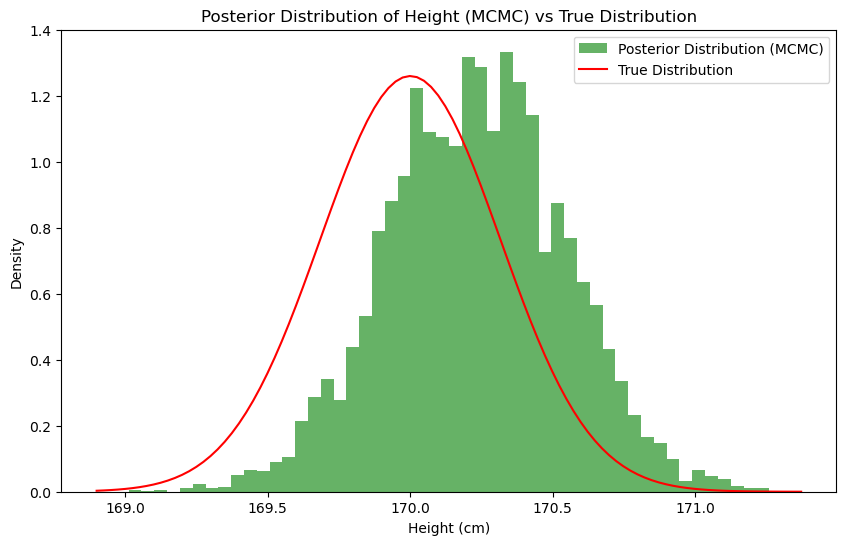

Posterior Mean: 170.22902709801852
Posterior Std: 0.31150718033358954


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 目标函数 - 假设测量数据服从高斯分布
def likelihood(h, data, sigma):
    return np.exp(-0.5 * np.sum((data - h)**2) / sigma**2)

# MCMC算法
def mcmc(data, sigma, n_iterations=10000, proposal_std=1):
    # 初始化身高
    h_current = np.mean(data)  # 使用测量数据的均值作为初始值
    samples = []

    for _ in range(n_iterations):
        # 从提议分布生成候选值
        h_proposed = h_current + np.random.normal(0, proposal_std)
        
        # 计算接受率
        alpha = min(1, likelihood(h_proposed, data, sigma) / likelihood(h_current, data, sigma))
        
        # 接受或拒绝候选值
        if np.random.rand() < alpha:
            h_current = h_proposed
        
        # 记录当前身高
        samples.append(h_current)
    
    return np.array(samples)

# 模拟数据 - 假设真实身高为170，测量数据有噪声
true_height = 170
n_measurements = 10
sigma = 1 # 假设噪声的标准差为1
measurements = np.random.normal(true_height, sigma, n_measurements)

# 运行MCMC
samples = mcmc(measurements, sigma, n_iterations=10000)

# 绘制结果
plt.figure(figsize=(10, 6))

# 绘制MCMC后验分布
plt.hist(samples, bins=50, density=True, alpha=0.6, color='g', label="Posterior Distribution (MCMC)")

# 绘制真实分布
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
true_dist = norm.pdf(x, loc=true_height, scale=sigma / np.sqrt(n_measurements))
plt.plot(x, true_dist, 'r-', label="True Distribution")

plt.title('Posterior Distribution of Height (MCMC) vs True Distribution')
plt.xlabel('Height (cm)')
plt.ylabel('Density')
plt.legend()
plt.show()

# 计算MCMC结果的均值和标准差
posterior_mean = np.mean(samples)
posterior_std = np.std(samples)

print(f"Posterior Mean: {posterior_mean}")
print(f"Posterior Std: {posterior_std}")


## MCMC参数拟合

该程序的目的是使用马尔科夫链蒙特卡洛（MCMC）方法对具有噪声的数据进行参数估计。我们利用MCMC方法从真实的正弦函数模型中提取参数$a$、$b$和$c$，并估计这些参数的最可能值及其不确定性。该方法对于复杂模型的参数推断尤其有用，尤其是当数据受到噪声干扰时。

该程序的意义在于：
1. **参数估计**：通过MCMC方法，我们能够从观测数据中提取最可能的参数，并计算出这些参数的置信区间。这对于科学研究中的许多实验数据分析非常重要。
2. **误差分析**：通过对参数进行多次采样并计算其标准差，我们能够了解这些估计值的误差范围，从而得出更可靠的科学结论。

### 算法

该程序采用了以下步骤来实现参数估计：

1. **模型定义**：定义了一个正弦函数模型$y = a \sin(bx + c)$，其中$a$、$b$、$c$是待估计的参数，$x$是已知的自变量，$y$是观测到的因变量。

2. **数据生成**：根据真实的模型参数和给定的噪声标准差，生成了一组带有噪声的观测数据。

3. **对数似然函数**：定义了一个对数似然函数，该函数用来衡量给定参数集与观测数据之间的匹配程度。对数似然函数是最大似然估计的基础。

4. **MCMC采样**：使用Metropolis-Hastings算法进行MCMC采样，迭代地从当前参数值出发，提出新的参数候选值，并根据对数似然比来决定是否接受新参数。采样过程中计算并记录每次接受的参数。

5. **估计参数**：通过计算MCMC采样的均值和标准差，得到了每个参数的最可能值和不确定性。

6. **结果展示**：使用`corner`模块绘制参数的分布图，并在图中显示每个参数的估计值及其标准差，从而直观展示参数估计的结果。

该算法的核心在于MCMC采样，它通过随机步进和接受准则有效地探索参数空间，最终获得各参数的最佳估计值及其误差。这种方法不依赖于参数空间的维度或复杂性，能够处理高维和复杂的模型。

### $\textcolor{red}{思考}$

MCMC如何给出置信度和误差的？

MCMC 最终输出的不是"一个最优参数点"，而是**参数空间中一条漫游的轨迹**。一旦链收敛到稳态，轨迹上的每一个点 $(a_i, b_i, c_i)$ 都可以看作是从真实后验分布 $p(a,b,c \mid D)$ 中抽取的一个样本。置信度（或更准确地说是**贝叶斯可信区间**）就是直接从这条轨迹的**统计特征**中读出来的。

---

1. 样本即分布

假设你跑了 10 万步 MCMC，扔掉前面的 burn-in 后，剩下 8 万个样本：

$$\{(a_1,b_1,c_1),\;(a_2,b_2,c_2),\;\dots,\;(a_{80000},b_{80000},c_{80000})\}$$

这些样本的**经验分布**就是后验分布 $p(a,b,c\mid D)$ 的蒙特卡洛近似。你不需要知道 $p(a,b,c\mid D)$ 的解析式，也不需要做高维积分——**分布的所有信息都蕴藏在样本的排列之中**。

---

2. 一维参数的可信区间：直接数分位数

如果你想问"参数 $a$ 的 $95\%$ 可信区间是多少"，只需把 8 万个 $a$ 样本从小到大排序：

- **等尾区间（Equal-tailed Interval）**：取排序后第 $2.5\%$ 分位数和第 $97.5\%$ 分位数之间的区间。例如，若 $a_{(2.5\%)}=2.1$，$a_{(97.5\%)}=3.4$，则

$$P(2.1 \le a \le 3.4 \mid D) \approx 0.95$$

这表示：根据后验分布，参数 $a$ 落在 $[2.1, 3.4]$ 内的概率是 $95\%$。

- **最高后验密度区间（HPD）**：找到最窄的区间，使得区间内包含 $95\%$ 的样本，且区间内每一点的概率密度都不低于区间外。如果后验是对称单峰的，HPD 与等尾区间重合；如果后验偏斜或多峰，HPD 更紧凑且更贴近"最可能值聚集在哪里"的直觉。

---

3. 多参数联合分布与 corner 图

你的正弦拟合有三个参数 $(a,b,c)$。它们的**联合**后验是一个三维分布。corner 图（也叫三角图）展示的是：

- **对角线**：每个参数的**边际后验分布** $p(a\mid D)$、$p(b\mid D)$、$p(c\mid D)$，由直方图或核密度估计（KDE）画出。图上标注的垂直虚线通常就是中位数或均值，阴影带就是 $68\%$ 或 $95\%$ 可信区间。
- **非对角线**：每两个参数之间的**二维边际分布** $p(a,b\mid D)$、$p(a,c\mid D)$、$p(b,c\mid D)$，以等高线或散点密度图呈现。这些椭圆（或扭曲的 blob）直观地显示了参数之间的**相关性**和**联合不确定性**。

例如，如果 $a$ 和 $b$ 的二维边际分布呈倾斜椭圆，说明这两个参数存在**简并**（degeneracy）：你增大 $a$ 的同时减小 $b$，模型输出可能几乎不变。这种相关性是 MCMC 天然捕捉到的，而传统最小二乘拟合往往只给对角化的误差条，会低估真实的联合不确定性。

---

4. 标准差从何而来？

你提到的"不确定性"或"误差范围"，通常就是样本的标准差：

$$\sigma_a = \sqrt{\frac{1}{N-1}\sum_{i=1}^N (a_i - \bar{a})^2}$$

在正态近似下，$\bar{a} \pm 2\sigma_a$ 大致对应 $95\%$ 的可信区间。但 MCMC 的优势恰恰在于**不需要做正态近似**——如果后验明显非正态（比如 $b$ 接近物理边界导致截断），直接从样本取分位数比用 $\pm\sigma$ 准确得多。




Acceptance rate: 0.05


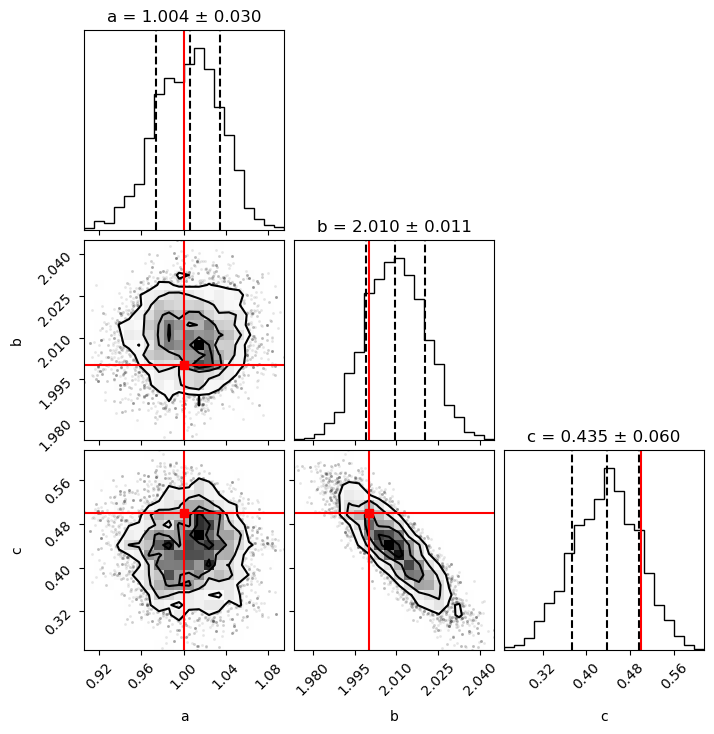

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import corner

# 定义模型
def true_function(a, b, c, x):
    return a * np.sin(b * x + c)

# 生成数据
true_a, true_b, true_c = 1.0, 2.0, 0.5  # 真实参数
sigma = 0.1  # 噪声标准差
x = np.linspace(0, 10, 20)
y_observed = true_function(true_a, true_b, true_c, x) + np.random.normal(0, sigma, len(x))

# 定义对数似然函数
def log_likelihood(params, x, y_observed, sigma):
    a, b, c = params
    y_predicted = true_function(a, b, c, x)
    return -0.5 * np.sum((y_observed - y_predicted) ** 2) / (sigma ** 2)

# MCMC 采样
samples = []
current_params = [1.0, 2.0, 0.5]  # 初始参数 [a, b, c]
acceptance_rate = 0

for _ in range(10000):
    # 生成新参数提议
    new_params = current_params + np.random.normal(0, 0.01, 3)  # 调整步长
    
    # 计算对数似然比
    log_alpha = log_likelihood(new_params, x, y_observed, sigma) - log_likelihood(current_params, x, y_observed, sigma)
    
    # 接受或拒绝新参数
    if np.log(np.random.rand()) < log_alpha:
        current_params = new_params
        acceptance_rate += 1
    
    samples.append(current_params)

samples = np.array(samples)
acceptance_rate /= 100000
print(f"Acceptance rate: {acceptance_rate:.2f}")

# 计算参数的估计值（均值和 1-sigma 误差）
means = np.mean(samples, axis=0)
stds = np.std(samples, axis=0)

# 绘制参数分布
figure = corner.corner(
    samples,                       # (N, 3) 的 MCMC 样本数组
    labels=["a", "b", "c"],        # 坐标轴标签
    truths=[true_a, true_b, true_c],  # 真实参数值，图中以红线标出
    truth_color="red",             # 真实值标记颜色
    quantiles=[0.16, 0.5, 0.84],   # 对角线上标注的分位数
                                   # 0.5 是中位数，0.16/0.84 对应 ±1σ（68% 区间）
    show_titles=True,              # 在对角线子图上方显示标题
    title_fmt=".3f",               # 标题数值格式：保留 3 位小数
    title_kwargs={"fontsize": 12}  # 标题字体大小
)

# 在图中显示均值和标准差
axes = np.array(figure.axes).reshape((3, 3))
for i in range(3):
    ax = axes[i, i]
    ax.set_title(f"{['a', 'b', 'c'][i]} = {means[i]:.3f} ± {stds[i]:.3f}", fontsize=12)

plt.show()

## MCMC 采样程序解析-- 宇宙学参数拟合应用

该程序使用自适应 Metropolis-Hastings 算法拟合宇宙学参数 Ωₘ 和 H₀。通过利用 CAMB 模拟的 CMB 功率谱数据和插值方法，我们能够有效地进行 MCMC 采样，并估计这些参数。以下是程序的各个步骤解析：

### 1. **预计算 CMB Power Spectrum 网格**

为了提高计算效率，我们首先预计算了宇宙学参数（Ωₘ 和 H₀）范围内的 CMB 功率谱。通过为不同参数值生成一个功率谱网格，我们在 MCMC 采样过程中可以通过插值来快速估算 CMB 功率谱，而无需每次都重新计算。

### 2. **插值函数**

在得到预计算的 CMB 功率谱网格后，我们使用插值方法将其转化为一个函数，以便在采样过程中快速计算对应宇宙学参数下的 CMB 功率谱。这避免了每次都要调用 CAMB。

### 3. **计算 CMB Power Spectrum**

使用插值函数，给定 Ωₘ 和 H₀ 参数值，我们可以在预先计算好的网格中进行插值，快速得到对应的 CMB 功率谱。这大大加速了模型计算，避免了在每次 MCMC 迭代中进行复杂的 CMB 模拟。

### 4. **定义目标分布（对数后验概率）**

目标分布是通过计算模型预测的 CMB 数据与实际“观测”数据之间的差异来定义的。我们使用了对数似然函数来衡量当前模型与观测数据的吻合程度，目标分布的公式如下：

$$
\log(\mathcal{L}(\theta)) = -0.5 \sum_{l} \left( \frac{C_l^{\text{obs}} - C_l^{\text{model}}}{\sigma_l} \right)^2
$$

### 5. **Metropolis-Hastings MCMC**

我们使用自适应 Metropolis-Hastings 算法进行 MCMC 采样。

### 6. **绘制结果**

最终，我们绘制了真实 CMB 数据与 MCMC 模拟的 CMB 数据的拟合效果，并展示了两个参数（Ωₘ 和 H₀）的后验分布。通过这些图像，我们能够直观地评估拟合结果和后验分布。

### 7. **总结**

本程序使用自适应 Metropolis-Hastings MCMC 方法进行参数估计，结合了 CAMB 模拟的 CMB 数据和插值技术。最终 成功地估计了 Ωₘ 和 H₀ 的后验分布。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import camb
from camb import model
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import multivariate_normal
import corner

# 1. **预计算 CMB Power Spectrum Grid**
def generate_cmb_grid(omega_m_vals, H0_vals, l_max=1000):
    """生成 CMB 功率谱 Cl 样本点"""
    cl_grid = np.zeros((len(omega_m_vals), len(H0_vals), l_max))

    for i, om_m in enumerate(omega_m_vals):
        for j, H0 in enumerate(H0_vals):
            pars = camb.CAMBparams()
            pars.set_cosmology(H0=H0, ombh2=0.022, omch2=om_m * (H0 / 100) ** 2)
            pars.InitPower.set_params(ns=0.965, As=2.1e-9)
            pars.set_for_lmax(l_max, lens_potential_accuracy=0)
            results = camb.get_results(pars)
            cl_grid[i, j, :] = results.get_unlensed_total_cls(CMB_unit="muK")[:l_max, 0]
    
    return cl_grid

# 2. **定义插值网格**
omega_m_vals = np.linspace(0.25, 0.35, 10)  # Omega_m 取 10 个点
H0_vals = np.linspace(65, 75, 10)  # H0 取 10 个点
cmb_grid = generate_cmb_grid(omega_m_vals, H0_vals)

# 3. **创建插值函数**
cmb_interpolator = RegularGridInterpolator((omega_m_vals, H0_vals), cmb_grid, method='nearest')

In [ ]:
# 4. **快速计算 CMB Power Spectrum**
def fast_get_cmb_power_spectrum(params):
    """使用插值快速估算 CMB 功率谱"""
    om_m, H0 = params
    om_m = np.clip(om_m, omega_m_vals[0], omega_m_vals[-1])
    H0 = np.clip(H0, H0_vals[0], H0_vals[-1])
    return cmb_interpolator([om_m, H0])[0]

# 5. **生成“观测”数据**
true_params = [0.3, 70]  # 真实参数
true_cl = fast_get_cmb_power_spectrum(true_params)

# 添加噪声
noise_level = np.maximum(0.5* true_cl, 1e-6)  # 50% 误差
planck_data = true_cl + np.random.normal(0, noise_level)

# 6. **定义目标分布**
def log_target(params):
    """计算目标分布的对数"""
    Omega_m, H0 = params
    if Omega_m < 0.25 or Omega_m > 0.35 or H0 < 65 or H0 > 75:
        return -np.inf  # 超出范围直接拒绝

    cmb_model = fast_get_cmb_power_spectrum(params)
    return -0.5 * np.sum((planck_data - cmb_model) ** 2 / noise_level**2)

# 7. **执行 Metropolis-Hastings MCMC**
def metropolis_hastings(log_prob, initial_params, initial_cov, n_samples=5000):
    """执行 Metropolis-Hastings MCMC 采样"""
    samples = []
    current_params = np.array(initial_params)
    current_log_prob = log_prob(current_params)

    for step in range(n_samples):
        new_params = np.random.multivariate_normal(current_params, initial_cov)
        new_log_prob = log_prob(new_params)

        # 计算接受概率
        acceptance_ratio = np.exp(new_log_prob - current_log_prob)
        if np.random.rand() < acceptance_ratio:
            current_params = new_params
            current_log_prob = new_log_prob

        samples.append(current_params)

    return np.array(samples)

# 8. **运行 MCMC**
initial_params = [0.3, 70]
initial_cov = np.array([[0.01, 0], [0, 0.1]])  # 调整协方差提高采样效率
samples = metropolis_hastings(log_target, initial_params, initial_cov, n_samples=100000)

# 9. **可视化 MCMC 结果**
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(samples[:, 0], label="Omega_m")
plt.xlabel("Step")
plt.ylabel("Omega_m")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(samples[:, 1], label="H0")
plt.xlabel("Step")
plt.ylabel("H0")
plt.legend()

plt.show()